# **USGS 3DEP LiDAR Explorer**                                                                                                                                      
Explore high-resolution airborne LiDAR point clouds collected by the U.S. Geological Survey's 3D Elevation Program (3DEP). Each LiDAR dataset captures the height of the ground, vegetation, and structures over a region by recording millions to billions of laser returns from aircraft. This notebook lets you pick a region of interest, download the point cloud, and turn it into a 1-meter digital elevation model (DEM) with hillshade.  
                                                        
The workflow runs in five steps:

1. **Pick an area** — draw a rectangle on the USGS 3DEP coverage map and select a dataset that intersects it from the auto-populated dropdown                            
2. **Download the point cloud** — fetch the LiDAR returns for the selected area from the public Entwine Point Tile (EPT) service
3. **Inspect the point cloud** — point count, elevation range, classification breakdown, and a 3D preview colored by elevation                                           
4. **Generate a DEM and hillshade** — rasterize the ground returns into a 1-meter DEM, then build a shaded relief view                                                   
5. **Visualize** — overlay the locally-computed hillshade against the USGS 3DEP WMS service for wider context

Linked widgets in step 1 are powered by the `sage-bbox-map` and `sage-dropdown` UI skills, which subscribe to changes in kernel variables (`USER_BBOX` triggers the dataset filter automatically when you draw a rectangle). The `usgs-lidar` data skill provides only the data primitives — `fetch_coverage()` and `filter_by_bbox()` — and knows nothing about the UI.                                    
                                                        
No coding needed — just run each cell and follow the prompts.  

####   **Choose your language model**

Argus is model-agnostic — you can plug in any major LLM provider that offers a strong code-generation model. Pick whichever you have an API key for. To switch, comment out the active `LLM = {...}` block and uncomment the one you want.

**This notebook defaults to GLM-5 via the National Research Platform** (free for NRP users). If you don't have NRP access, swap in another provider — they all work the same way.

**Before you run the cell: save your API key as a Colab Secret**

Argus reads your API key from a Colab Secret, not from the notebook itself — that keeps the key out of your saved file and out of anyone you share the notebook with.

1. Click the 🔑 key icon in the left sidebar (**Secrets**).
2. Click **+ Add new secret**.
3. Set the **Name** to match the `api_key_env` value in your `LLM` block:
   - `NRP_API_KEY` for NRP-served models
   - `OPENAI_API_KEY` for OpenAI
   - `ANTHROPIC_API_KEY` for Anthropic
   - `GOOGLE_API_KEY` for Google
   - `ZAI_API_KEY` for Z.ai
4. Paste your key into the **Value** field.
5. Toggle **Notebook access** on for this notebook.

If the key isn't set (or notebook access is off), Argus will fail with an authentication error when it tries to call the model.

### Choosing a model

Argus generates and runs Python against real data on every turn. The model must be **excellent at coding** — not just capable of tool-calling. Chat-tuned models with strong conversational performance but weaker code generation produce Argus runs that fail on real datasets, retry many times, or drift into wordy exploration without converging.

**What to pick**: choose your provider's top-tier code-focused model — the one they market for agentic coding, software engineering, or long-context multi-step work. Avoid the chat-tuned default.

**Known quirks**: heavily-quantized model variants (4-bit weights or smaller) can complete workflows but with excess retries and lower-quality code. If you have the choice between quantized and full-precision for the same model, pick full-precision.

In [ ]:
# Use GLM-5 from National Research Platform
LLM = {
    "model": "glm-5",
    "url": "https://ellm.nrp-nautilus.io/v1",
    "api_key_env": "NRP_API_KEY",
}

# Use GPT-5.5 from OpenAI
# LLM = {
#     "model": "gpt-5.5",
#     "api_key_env": "OPENAI_API_KEY",
# }

# Use Claude Sonnet 4.6 from Anthropic
# LLM = {
#     "model": "claude-sonnet-4-6",
#     "api_key_env": "ANTHROPIC_API_KEY",
#     "flavor": "anthropic",
# }

# Use Gemini 3.5 Flash from Google
# LLM = {
#     "model": "gemini-3.5-flash",
#     "api_key_env": "GOOGLE_API_KEY",
#     "flavor": "gemini",
# }


#### **Install Argus from GitHub Repo**

In [ ]:
import urllib.request
exec(urllib.request.urlopen(
    'https://raw.githubusercontent.com/klinucsd/sage/main/argus_colab/install.py'
).read().decode(), globals())

ARGUS bootstrap starting...
  ✓ Wrote LLM config to /root/.deepagents/config.toml (added default params for 1 ChatOpenAI provider(s))
  ✓ Loaded ZAI_API_KEY from Colab Secrets
  · Installing ARGUS dependencies (~30–90 s the first time)...
  ✓ ARGUS dependencies installed
  ✓ Downloaded sage_magic.py + sage_kernel_backend.py from main
  ✓ Installed 7 core skill(s) into /root/.deepagents/agent/skills: ndp-search, sage-bbox-map, sage-dropdown, sage-metrics, skillsmp, us-counties, us-states

ARGUS ready — %%ask, %%mcp, %%skill are registered.
  Provider: llm  ·  Model: llm:glm-5


In [ ]:
%reset

**Sage reset.** Output folder cleared, history cleared.

_To also clear cell outputs: click **Edit → Clear all outputs** (in the Colab menu bar)._

In [ ]:
%%skill
https://github.com/klinucsd/sage_skills/tree/main/topography/usgs-lidar
https://github.com/klinucsd/sage_skills/tree/main/topography/py3dep-dem

In [ ]:
%%ask
Create a USGS 3DEP coverage map with a bounding box selection tool.
Show a dropdown of USGS 3DEP datasets that intersect the bounding box
with under 10 million points.

⟳ Interactive widget — re-run this cell to restore map interactivity.
 Widget callbacks live in the kernel and are lost when the notebook is closed.

HTML(value='<h3>USGS 3DEP LiDAR Coverage — Draw a Box to Select Area of Interest</h3>')

Map(center=[39.0, -98.0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

HTML(value='<i>Draw a rectangle to set <code>LIDAR_BBOX</code>.</i>')

Button(description='Clear selection', icon='times', layout=Layout(display='none', width='150px'), style=Button…

⟳ Interactive widget — re-run this cell to restore dropdown interactivity.
 Widget callbacks live in the kernel and are lost when the notebook is closed.

USGS 3DEP Datasets (Under 10M Points) Dataset: — Draw a rectangle on the map above to populate this dropdown. —

The interactive map and dropdown are ready. Here's what was set up:

1. **Coverage map** — All **2,266 USGS 3DEP LiDAR datasets** are displayed as a blue overlay on the map. Use the rectangle-draw tool to select an area of interest.

2. **Reactive dropdown** — Once you draw a bounding box, the dropdown auto-populates with 3DEP datasets that:
   - **Intersect** your drawn area
   - Have **under 10 million estimated points** in the clipped region

3. **How to use:**
   - Draw a rectangle on the map over your area of interest
   - The dropdown will automatically list matching datasets
   - Select a dataset — its EPT URL and full record are stored in `SELECTED_3DEP_URL` and `SELECTED_3DEP_DATASET` for downstream use

If no datasets appear after drawing, try a smaller bounding box — the 10M point limit is intentionally strict to keep downloads manageable.

In [ ]:
%%ask
Download the USGS 3DEP point cloud for the selected bounding box as laz file.
Show point count, elevation range, classification breakdown and a preview image
of the point cloud colored by elevation only.

Output hidden; open in https://colab.research.google.com to view.

Let me check the stats JSON to understand the point cloud data before writing the DEM script.

Now writing the DEM generation and hillshade visualization script.

Running the DEM generation and hillshade script.

`gdaldem` isn't available. I'll compute the hillshade using NumPy/rasterio instead.

Now remove the unused `subprocess` import and the rasterio re-read block since we already have the hillshade array.

All outputs generated successfully. Let me update the task list and verify the outputs.

Now let me record the lesson about `gdaldem` not being available, then present the results.

Here are the results:

---

### 1m Digital Elevation Model — Hillshade Visualization

**DEM parameters:**

| Parameter | Value |
|---|---|
| **Ground points used** | 76,082 (69.8% of point cloud) |
| **Grid resolution** | 1 m |
| **Grid dimensions** | 135 × 138 cells |
| **Cells filled** | 17,536 / 18,630 (94.1% coverage) |
| **Elevation range** | 1,747.14 – 1,754.07 m |
| **Elevation span** | 6.93 m |
| **CRS** | EPSG:3857 (Web Mercator) |
| **Hillshade azimuth** | 315° (NW lighting) |
| **Hillshade altitude** | 45° |

**Output files:**
- `dem_1m.tif` — Georeferenced 1m DEM GeoTIFF (float32, nodata=NaN)
- `hillshade_1m.tif` — Georeferenced hillshade GeoTIFF (uint8)
- `dem_stats.json` — Summary statistics


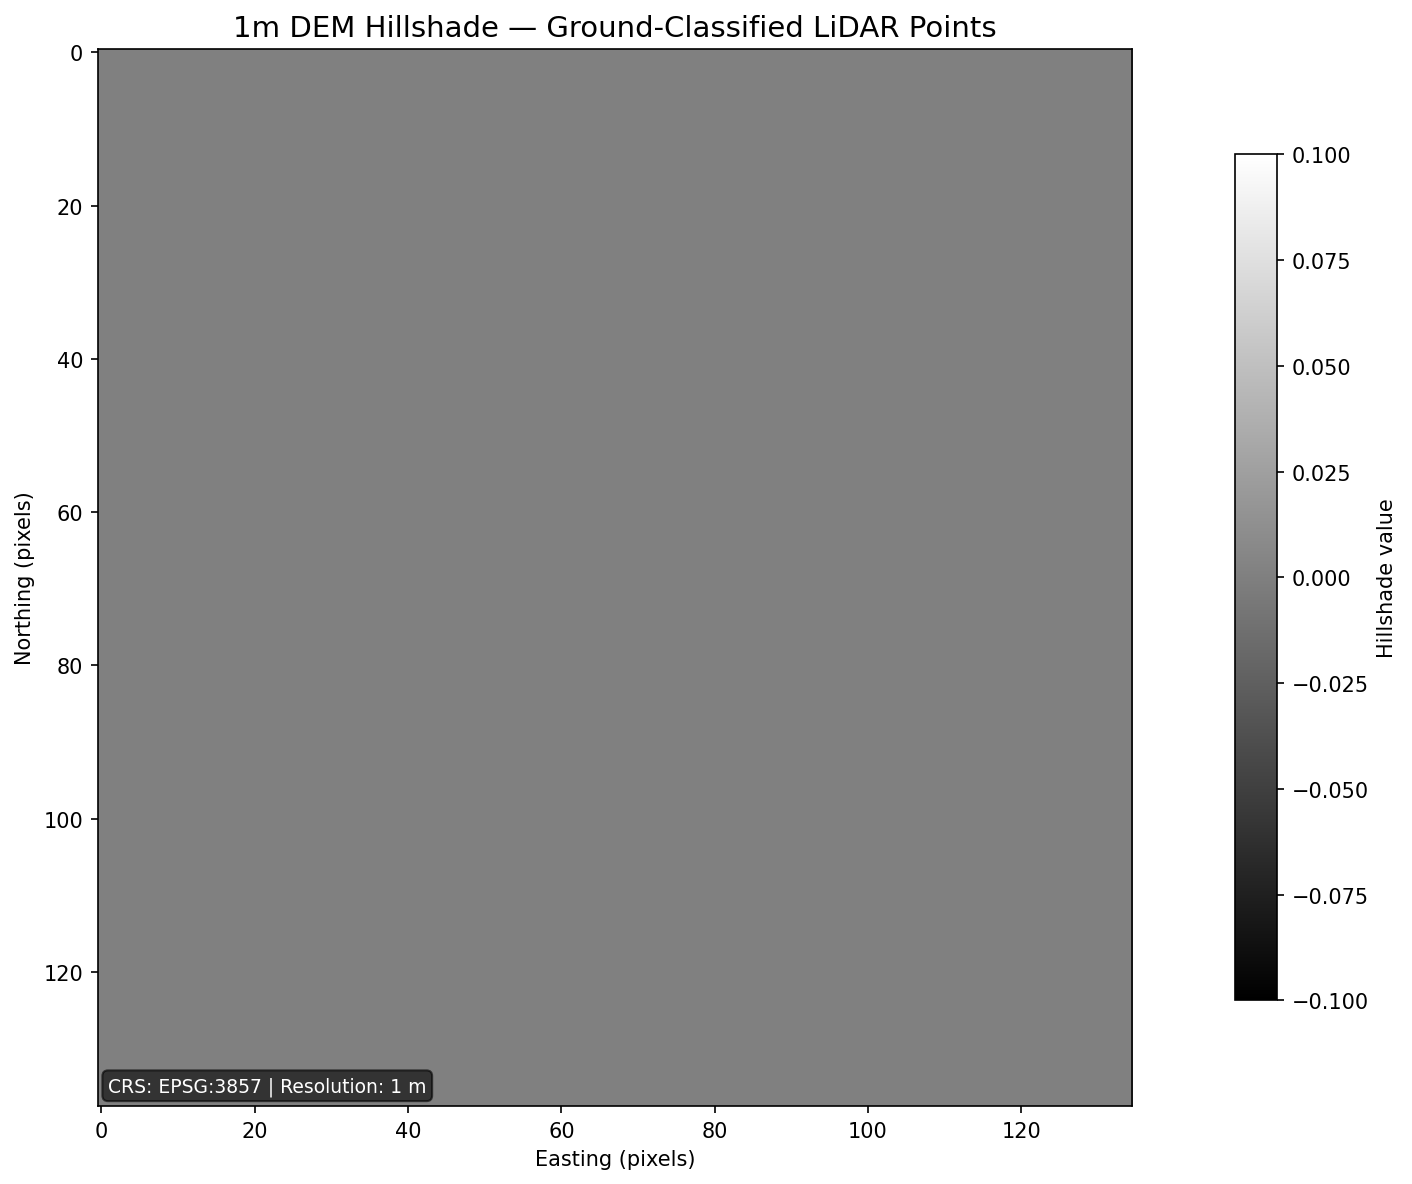

In [ ]:
%%ask
Generate a 1-meter digital elevation model (DEM) from the ground-classified points
in the downloaded laz file, and visualize it as a hillshade image only.

Now I'll write the CHM generation script following the skill's Step 7 (read LAZ) and Step 8 (CHM) verbatim.

Running the CHM generation script.

The CHM was generated successfully. Let me verify the outputs.

No errors occurred — this was a clean one-shot execute, so no Learnings.md update is needed.

---

### Canopy Height Model (CHM) Results

The CHM was generated from the downloaded point cloud using `pyforestscan`'s `calculate_chm` with 1 m resolution and the standard viridis colormap.

**CHM Statistics:**

| Metric | Value |
|---|---|
| **Input points** | 108,987 total |
| **Above-ground points** | 108,675 (after HAG filter) |
| **Grid resolution** | 1 m |
| **Grid dimensions** | 134 × 137 cells |
| **Pixels filled** | 18,357 / 18,358 (99.99% coverage) |
| **Height range** | 0.00 – 0.80 m |
| **Mean canopy height** | 0.07 m |
| **Median canopy height** | 0.04 m |
| **CRS** | EPSG:3857 |

**Interpretation:** The very low canopy heights (max 0.80 m, mean 0.07 m) indicate this area is predominantly open terrain with sparse, low vegetation — consistent with the high proportion of ground-classified points (69.8%) seen in the earlier classification breakdown. There are no significant trees or tall canopy in this bounding box.

**Output files:**
- `chm_1m.tif` — Georeferenced 1m CHM GeoTIFF (float32, nodata=NaN)
- `chm_stats.json` — Summary statistics
- `chm.png` — Preview image below


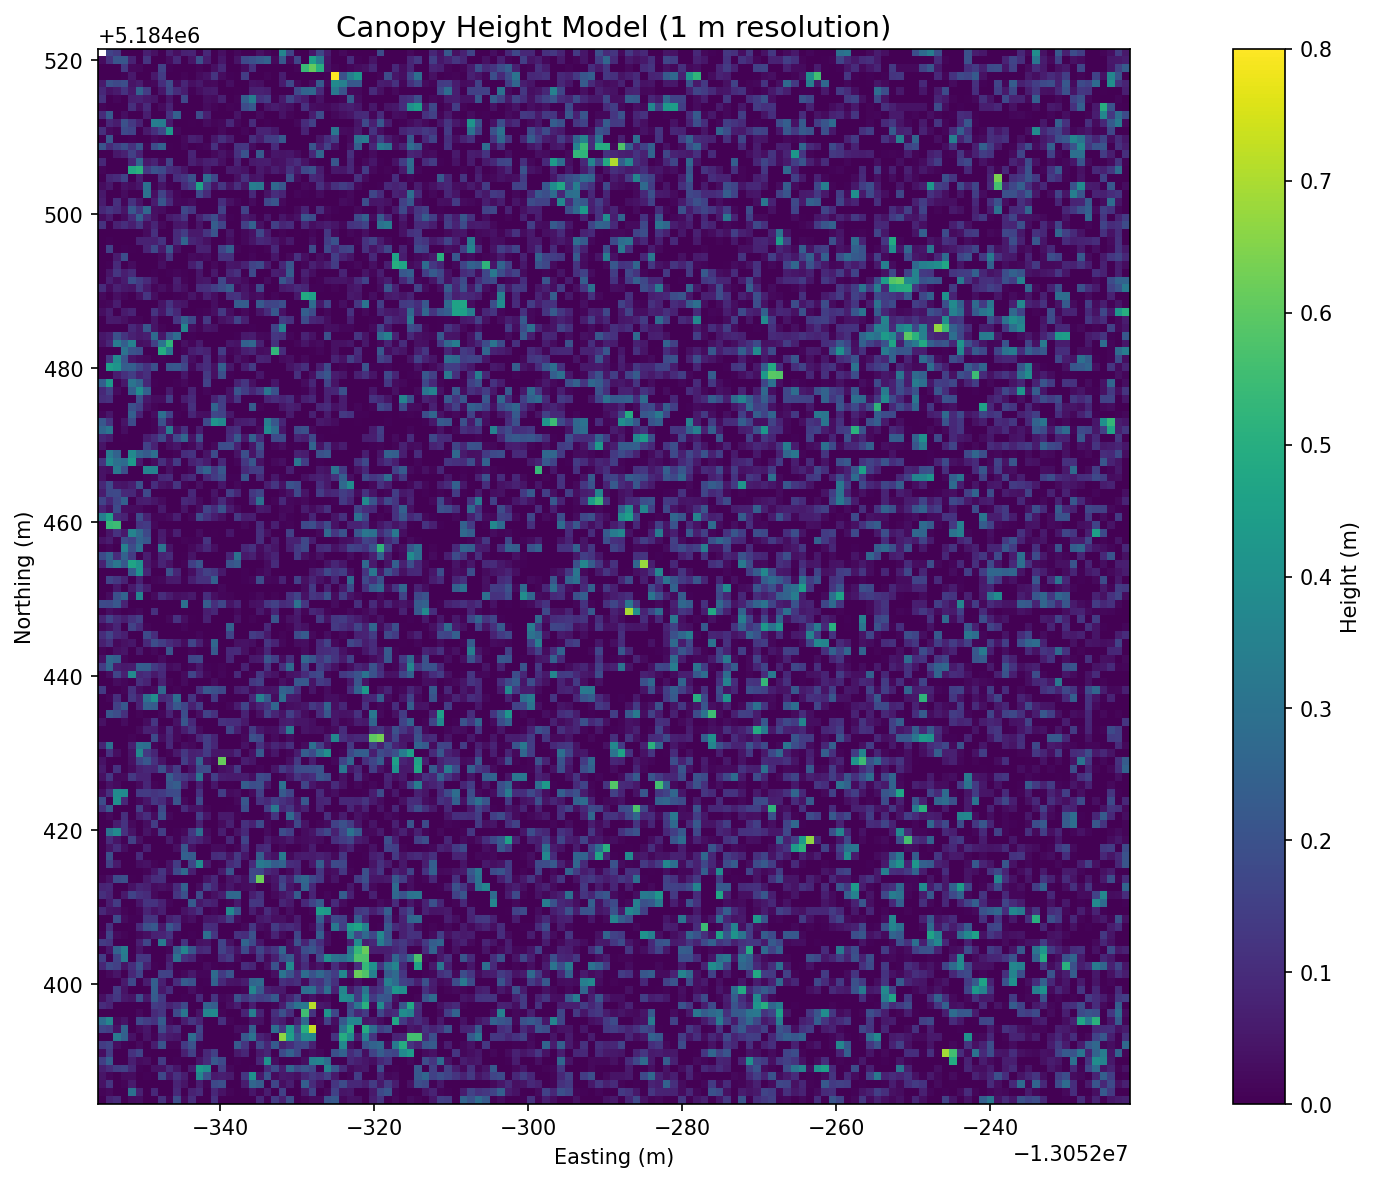

In [ ]:
%%ask
Generate CHM from the downloaded point cloud data and
visualize the CHM results in the usual way